In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/raw/dataset_phishing.csv")

X = df.drop(columns=["status", "url"])
y = df["status"].map({"legitimate": 0, "phishing": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


X_train: (9144, 87)
X_test: (2286, 87)


In [3]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [4]:
print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))


Random Forest Results
Accuracy: 0.9601924759405074
Precision: 0.9565972222222222
Recall: 0.9641294838145232
F1 Score: 0.9603485838779956
ROC-AUC: 0.9935217524756037

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.96      0.96      1143
           1       0.96      0.96      0.96      1143

    accuracy                           0.96      2286
   macro avg       0.96      0.96      0.96      2286
weighted avg       0.96      0.96      0.96      2286



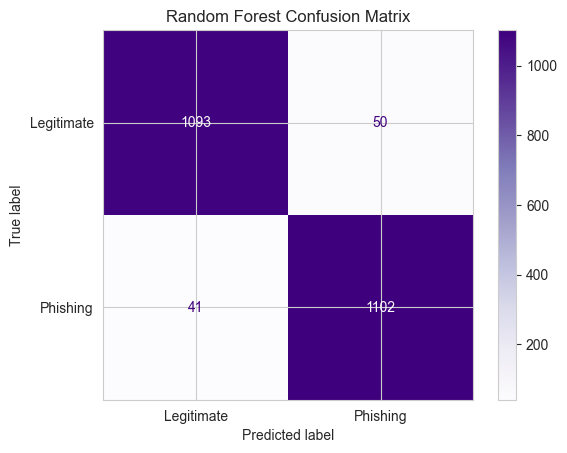

In [5]:
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitimate", "Phishing"])
disp.plot(cmap="Purples")
plt.title("Random Forest Confusion Matrix")
plt.show()


In [6]:
comparison_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [0.936133, 0.924322, accuracy_score(y_test, y_pred_rf)],
    "Precision": [0.939207, 0.936937, precision_score(y_test, y_pred_rf)],
    "Recall": [0.932633, 0.909886, recall_score(y_test, y_pred_rf)],
    "F1 Score": [0.935909, 0.923213, f1_score(y_test, y_pred_rf)],
    "ROC-AUC": [0.981422, 0.962410, roc_auc_score(y_test, y_prob_rf)]
})

comparison_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.936133,0.939207,0.932633,0.935909,0.981422
1,Decision Tree,0.924322,0.936937,0.909886,0.923213,0.962410
2,Random Forest,0.960192,0.956597,0.964129,0.960349,0.993522


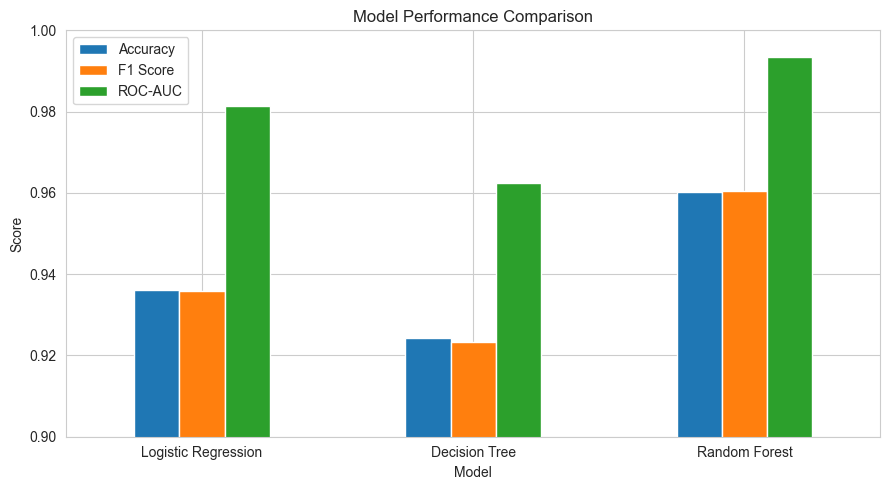

In [7]:
comparison_results.set_index("Model")[["Accuracy", "F1 Score", "ROC-AUC"]].plot(
    kind="bar",
    figsize=(9, 5)
)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0.90, 1.0)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [8]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

In [9]:
print("Gradient Boosting Results")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall:", recall_score(y_test, y_pred_gb))
print("F1 Score:", f1_score(y_test, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_gb))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Results
Accuracy: 0.9531933508311461
Precision: 0.9496527777777778
Recall: 0.9571303587051618
F1 Score: 0.9533769063180828
ROC-AUC: 0.9904925488863324

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.95      0.95      1143
           1       0.95      0.96      0.95      1143

    accuracy                           0.95      2286
   macro avg       0.95      0.95      0.95      2286
weighted avg       0.95      0.95      0.95      2286



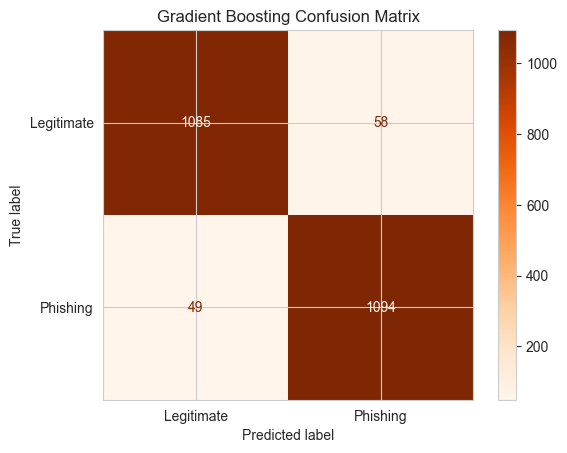

In [10]:
cm = confusion_matrix(y_test, y_pred_gb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitimate", "Phishing"])
disp.plot(cmap="Oranges")
plt.title("Gradient Boosting Confusion Matrix")
plt.show()


In [11]:
full_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "Gradient Boosting"],
    "Accuracy": [0.936133, 0.924322, 0.960192, 0.953193],
    "Precision": [0.939207, 0.936937, 0.956597, 0.949653],
    "Recall": [0.932633, 0.909886, 0.964129, 0.957130],
    "F1 Score": [0.935909, 0.923213, 0.960349, 0.953377],
    "ROC-AUC": [0.981422, 0.962410, 0.993522, 0.990493]
})

full_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.936133,0.939207,0.932633,0.935909,0.981422
1,Decision Tree,0.924322,0.936937,0.909886,0.923213,0.962410
2,Random Forest,0.960192,0.956597,0.964129,0.960349,0.993522
3,Gradient Boosting,0.953193,0.949653,0.957130,0.953377,0.990493


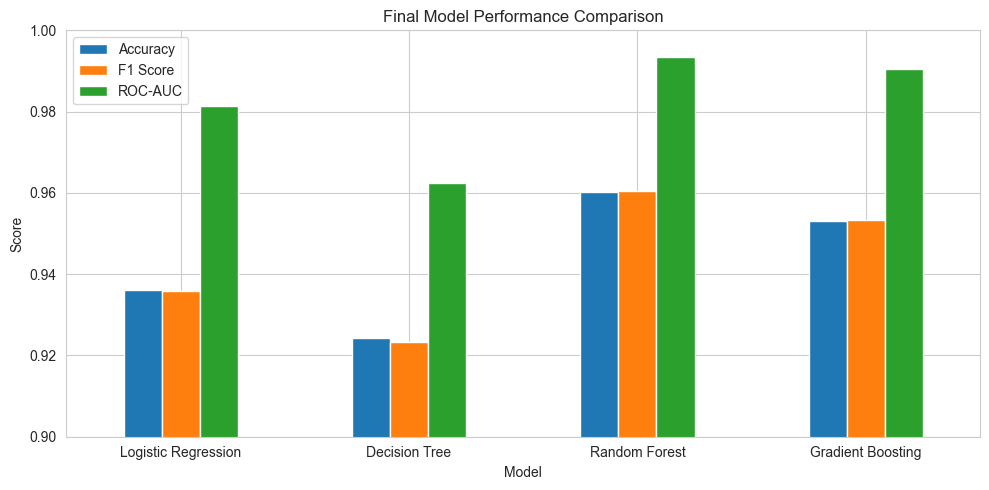

In [12]:
full_results.set_index("Model")[["Accuracy", "F1 Score", "ROC-AUC"]].plot(
    kind="bar",
    figsize=(10, 5)
)
plt.title("Final Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0.90, 1.0)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [13]:
feature_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top_features = feature_importances.sort_values(ascending=False).head(15)

print(top_features)

google_index            0.180706
page_rank               0.098928
nb_hyperlinks           0.090801
web_traffic             0.072582
nb_www                  0.041813
domain_age              0.033736
phish_hints             0.030551
ratio_extHyperlinks     0.028223
safe_anchor             0.024556
ratio_intHyperlinks     0.023865
ratio_extRedirection    0.022831
longest_word_path       0.022125
length_url              0.017201
length_words_raw        0.016914
ratio_digits_url        0.016765
dtype: float64


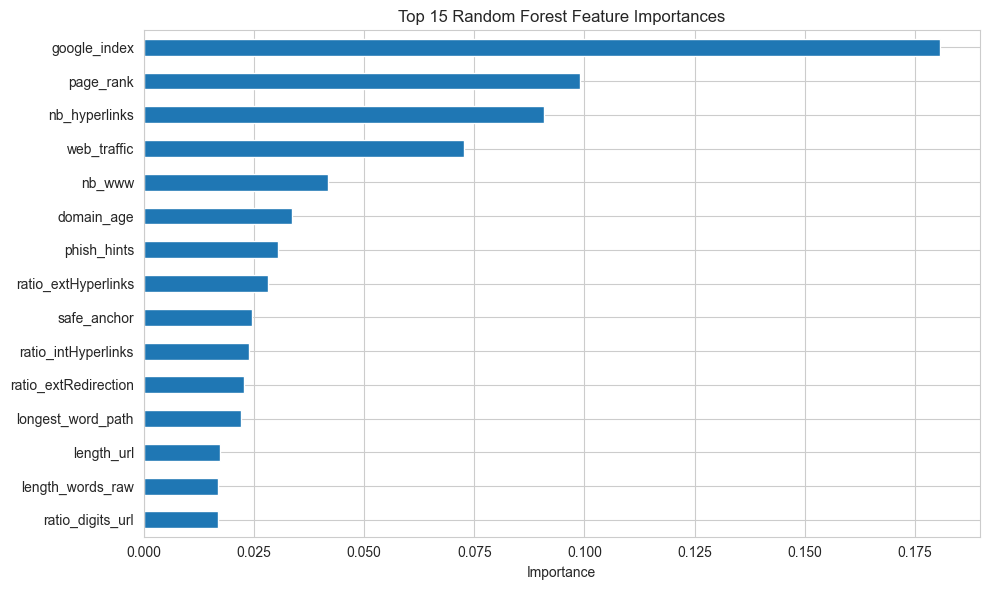

In [14]:
plt.figure(figsize=(10, 6))
top_features.sort_values().plot(kind="barh")
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()
